<div style="background: linear-gradient(to right, #003366, #005b96); color: white; padding: 20px; border-radius: 10px; margin-bottom: 16px; box-shadow: 0 4px 8px rgba(0,0,0,0.1);">
  <div style="text-align: center;">
    <h1 style="margin: 0; font-family: 'Helvetica Neue', Helvetica, Arial, sans-serif; font-weight: 700; letter-spacing: 1px;">Data Mining</h1>
    <div style="font-size: 20px; margin-top: 8px; font-weight: 300;">Amazing International Airlines Inc.</div>
    <div style="font-size: 18px; margin-top: 4px; opacity: 0.9;">Clustering - Fuzzy Clustering</div>
    <hr style="margin: 16px auto; width: 200px; border: 0; border-top: 1px solid rgba(255,255,255,0.5);">
    <div style="font-size: 14px; opacity: 0.8;">Group 92 • Notebook • 2025/2026</div>
  </div>
</div>

| Student Name | Student ID | Email |
| :--- | :--- | :--- |
| **Mehmet Karaca** | 20250344 | 20250344@novaims.unl.pt |
| **Duarte Gomes** | 20250017 | 20250017@novaims.unl.pt |
| **Esra Salhi** | 20250537 | 20250537@novaims.unl.pt |

## Table of Contents

1. [Introduction](#introduction)
    - 1.1. [Importing Libraries](#importing-libraries)
    - 1.2. [Data Loading](#loading-and-reading-data)
2. [Fuzzy Clustering: Value-Based Perspective](#value-based-clustering)
    - 2.1. [Model Execution](#value-model)
    - 2.2. [Identification of Hybrid Customers](#value-hybrid)
    - 2.3. [Comparison with K-Means](#value-comparison)
    - 2.4. [Strategic Insights: Value Sensitivity](#value-insights)
3. [Fuzzy Clustering: Demographic Perspective](#demographic-clustering)
    - 3.1. [Model Execution](#demo-model)
    - 3.2. [Identification of Hybrid Customers](#demo-hybrid)
    - 3.3. [Comparison with K-Means](#demo-comparison)
    - 3.4. [Strategic Insights: Demographic Rigidity](#demo-insights)

# 1. Introduction <a id="introduction"></a>

This notebook extends the primary segmentation analysis by implementing **Fuzzy C-Means (FCM) Clustering**. Unlike hard clustering algorithms such as K-Means, which enforce exclusive cluster membership, FCM assigns membership probabilities to each data point for multiple clusters. 

This methodology is instrumental in identifying "hybrid" customers—individuals exhibiting characteristics of multiple segments—thereby enabling more nuanced targeting strategies for customers in transitional states. By quantifying the degree of membership across different clusters, we can better understand the fluidity of customer behavior and demographics.

## 1.1. Importing Libraries <a id="importing-libraries"></a>

We begin by importing the necessary libraries for data manipulation, statistical analysis, clustering, and visualization.
*   **Data Manipulation:** `pandas`, `numpy`
*   **Visualization:** `matplotlib`, `seaborn`, `plotly`
*   **Clustering & Evaluation:** `sklearn` (KMeans, AgglomerativeClustering, metrics), `scipy` (dendrograms)


In [1]:
# Imports
import os
import math
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as Line2D
import matplotlib as mpl
import seaborn as sns
import plotly.express as px
from cycler import cycler
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.base import clone
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.neighbors import NearestNeighbors

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, MeanShift, estimate_bandwidth
from sklearn.mixture import GaussianMixture
from minisom import MiniSom

from sklearn.metrics import silhouette_score, davies_bouldin_score
from collections import Counter


import skfuzzy as fuzz

## 1.2. Loading and Reading Data <a id="loading-and-reading-data"></a>

We load the dataset that has been processed and clustered in the previous stages of our analysis.

In [2]:
# directory with raw CSV files
data_dir = Path("data/outputs/")

raw_data = pd.read_csv(data_dir / "customers_with_clusters.csv")

In [3]:
# Print all columns of the dataframe
pd.set_option('display.max_columns', None)
raw_data.head()

,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,average_distance_per_flight,points_redemption_ratio,companion_flight_ratio,LoyaltyStatus_Nova,LoyaltyStatus_Star,EnrollmentType_Standard,Gender_male,Education_College,Education_Doctor,Education_High School or Below,Education_Master,Marital Status_Married,Marital Status_Single,Province or State_British Columbia,Province or State_Manitoba,Province or State_New Brunswick,Province or State_Newfoundland,Province or State_Nova Scotia,Province or State_Ontario,Province or State_Prince Edward Island,Province or State_Quebec,Province or State_Saskatchewan,Province or State_Yukon,Location Code_Suburban,Location Code_Urban,valuebased_cluster,demographic_cluster,merged_cluster
0,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,1.068659,Married,Star,2019-02-15,NaN,-0.605614,Standard,1,-0.072878,1.107125,0.853643,1.338111,1.338311,0.564680,0.576033,1.338112,-0.047634,0.342580,-0.715057,1.086341,0.270829,-0.995430,-0.582545,-0.213677,-0.221224,-0.177105,0.846863,-0.605314,-0.595242,-0.203962,-0.198541,-0.123754,-0.182176,1.448178,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,1.437326,0,4,V0_D4
1,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,-1.243243,Divorced,Star,2019-03-09,NaN,-0.605545,Standard,1,-0.102559,1.892954,-0.181654,0.843650,0.843514,1.591410,1.584071,0.843651,0.584566,-0.902122,-0.715057,1.086341,0.270829,1.004591,1.716605,-0.213677,-0.221224,-0.177105,-1.180828,-0.605314,-0.595242,-0.203962,-0.198541,-0.123754,-0.182176,-0.690523,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,-0.695737,3,2,V3_D2
2,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,Urban,-1.243243,Single,Star,2017-07-14,2021-01-08,-0.605524,Standard,0,0.229333,-0.292522,0.133436,-0.317820,-0.317841,-0.358503,-0.369294,-0.317819,-0.137006,0.342580,-0.715057,1.086341,0.270829,1.004591,1.716605,-0.213677,-0.221224,-0.177105,-1.180828,1.652035,1.679989,-0.203962,-0.198541,-0.123754,-0.182176,-0.690523,-0.063615,-0.493981,-0.156403,-0.080718,-0.716227,1.437326,3,2,V3_D2
3,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,-1.243243,Single,Star,2016-02-17,NaN,-0.605524,Standard,1,1.403096,0.555749,0.943669,0.592202,0.592203,0.887816,0.896561,0.592203,0.333447,0.454587,-0.715057,1.086341,0.270829,1.004591,1.716605,-0.213677,-0.221224,-0.177105,-1.180828,1.652035,-0.595242,-0.203962,-0.198541,-0.123754,-0.182176,1.448178,-0.063615,-0.493981,-0.156403,-0.080718,1.396205,-0.695737,3,2,V3_D2
4,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,1.981146,Married,Star,2017-10-25,NaN,-0.605080,2021 Promotion,1,0.572018,0.446770,1.123721,0.488742,0.488700,-0.987825,-0.987124,0.488742,-0.696816,0.702406,-0.715057,1.086341,-3.692371,1.004591,-0.582545,-0.213677,-0.221224,-0.177105,0.846863,-0.605314,-0.595242,-0.203962,-0.198541,-0.123754,-0.182176,-0.690523,-0.063615,2.024369,-0.156403,-0.080718,1.396205,-0.695737,0,1,V0_D1


# 2. Fuzzy Clustering: Value-Based Perspective <a id="value-based-clustering"></a>

In this section, we apply Fuzzy Clustering to the **Value-Based** features. <a id="value-model"></a>

The objective is to identify customers who fall "between" standard value categories (e.g., between High-Value and Mid-Value). Recognizing these transitional or hybrid customers is crucial for targeted marketing, as they may represent opportunities for upselling or require specific retention strategies that differ from those used for core segment members.

In [4]:
value_based_features = [
    'Customer Lifetime Value',
    'Income',
    'total_points_accumulated',
    'total_cost_redeemed']

In [5]:
# Prepare the matrix for skfuzzy (transpose required)
data_fuzzy_value = raw_data[value_based_features].T.values

data_fuzzy_value

array([[-0.60561361, -0.60554491, -0.60552444, ...,  9.68386195,
        11.01363526, 11.01363526],
       [ 1.06865904, -1.24324297, -1.24324297, ..., -1.24324297,
         0.69992013,  0.69992013],
       [ 1.33831053,  0.84351419, -0.31784142, ...,  1.21068558,
        -1.40068155, -1.78693442],
       [ 0.57603256,  1.58407092, -0.36929374, ...,  0.82804215,
        -0.38322975, -0.9871237 ]], shape=(4, 16375))

In [6]:
# Define parameters
n_clusters = 4 # Number of clusters (Same as in our previous KMeans)
m = 2.0     # Fuzzifier (default value)

# Fuzzy C-Means Training
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_fuzzy_value, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None
)

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

Fuzzy Partition Coefficient (FPC): 0.4046


In [7]:
# 1. Ensure fuzzy_data is an explicit copy
data_fuzzy_value = data_fuzzy_value.copy()

# 2. Assign membership probabilities (percentages)
for i in range(n_clusters):
    raw_data.loc[:, f'Value_Fuzzy_P{i}'] = u[i]

In [ ]:
# 3. Identify hybrid customers (Max probability < 70%)
# <a id="value-hybrid"></a>
prob_cols = [f'Value_Fuzzy_P{i}' for i in range(n_clusters)]
raw_data.loc[:, 'Is_Hybrid'] = raw_data[prob_cols].max(axis=1) < 0.7

# 4. Calculate statistics
hybrid_count = raw_data['Is_Hybrid'].sum()
total_count = len(raw_data)
hybrid_percentage = (hybrid_count / total_count) * 100

print("-" * 30)
print(f"Fuzzy Clustering Results:")
print(f"Total number of customers: {total_count}")
print(f"Number of hybrid customers: {hybrid_count}")
print(f"Percentage of hybrid customers: {hybrid_percentage:.2f}%")
print("-" * 30)

------------------------------
Fuzzy Clustering Results:
Total number of customers: 16375
Number of hybrid customers: 13833
Percentage of hybrid customers: 84.48%
------------------------------


/var/folders/91/np610d0s2kq3t3kpltqrl7b40000gn/T/ipykernel_64862/3405942699.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  raw_data['Fuzzy_Hard_Label'] = hard_clusters


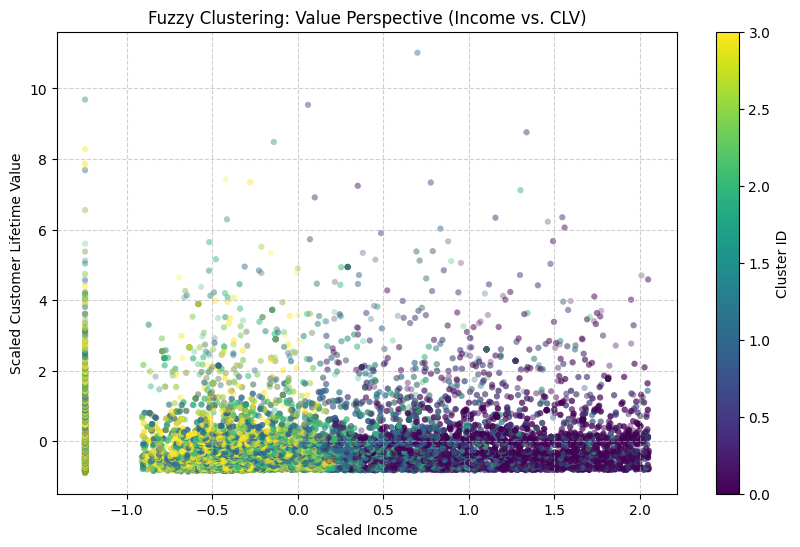

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Determine hard clusters and maximum probability
hard_clusters = np.argmax(u, axis=0)
max_probs = np.max(u, axis=0)

# Assign hard labels to dataframe for later use
raw_data['Fuzzy_Hard_Label'] = hard_clusters

plt.figure(figsize=(10, 6))

# 2. Scatter Plot: We use Income and CLV for the axes
# We plot each point individually to set the transparency (alpha) per point
# (For large datasets, you can also take a sample: .sample(2000))
scatter = plt.scatter(
    raw_data['Income'], 
    raw_data['Customer Lifetime Value'], 
    c=hard_clusters, 
    cmap='viridis',
    alpha=max_probs, # High probability = Strong color, Low = Pale
    edgecolors='none',
    s=20
)

plt.title('Fuzzy Clustering: Value Perspective (Income vs. CLV)')
plt.xlabel('Scaled Income')
plt.ylabel('Scaled Customer Lifetime Value')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

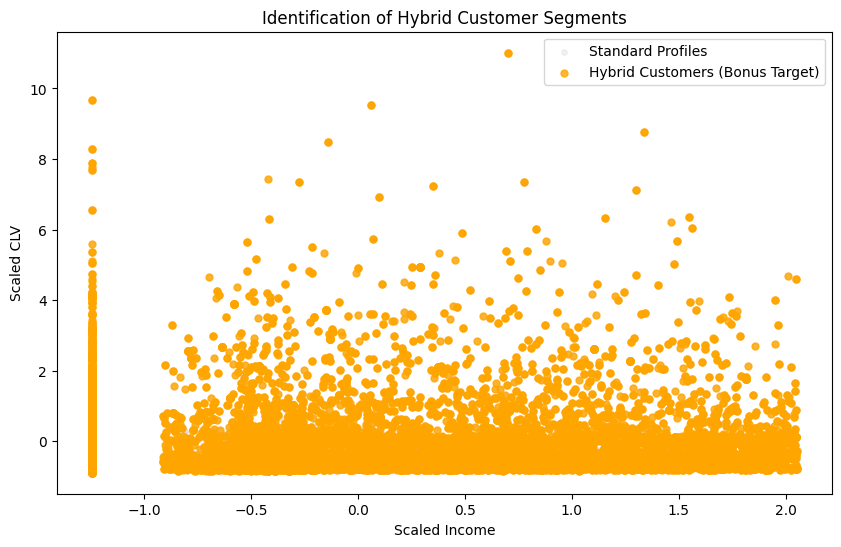

In [10]:
plt.figure(figsize=(10, 6))

# Background: All customers in light grey
plt.scatter(
    raw_data['Income'], 
    raw_data['Customer Lifetime Value'], 
    c='lightgrey', 
    alpha=0.3, 
    s=15, 
    label='Standard Profiles'
)

# Foreground: Only hybrid customers in a signal color (e.g., Red or Orange)
hybrids = raw_data[raw_data['Is_Hybrid'] == True]
plt.scatter(
    hybrids['Income'], 
    hybrids['Customer Lifetime Value'], 
    c='orange', 
    alpha=0.8, 
    s=25, 
    label='Hybrid Customers (Bonus Target)'
)

plt.title('Identification of Hybrid Customer Segments')
plt.xlabel('Scaled Income')
plt.ylabel('Scaled CLV')
plt.legend()
plt.show()

## 2.1. Comparison with K-Means Clustering <a id="value-comparison"></a>

In [11]:
# Mapping based on your analysis
cluster_mapping = {
    0: 'High Income',
    1: 'Low Points and Costs',
    2: 'High CLV',
    3: 'Low Income'
}

# Create new columns with readable names using .loc to avoid ChainedAssignmentError
raw_data.loc[:, 'valuebased_cluster_name'] = raw_data['valuebased_cluster'].map(cluster_mapping)

# IMPORTANT: Briefly check if the Fuzzy Cluster IDs (0-3) have the same meaning as in K-Means.
# If so, you can map them directly:
raw_data.loc[:, 'Fuzzy_Hard_Label_name'] = raw_data['Fuzzy_Hard_Label'].map(cluster_mapping)

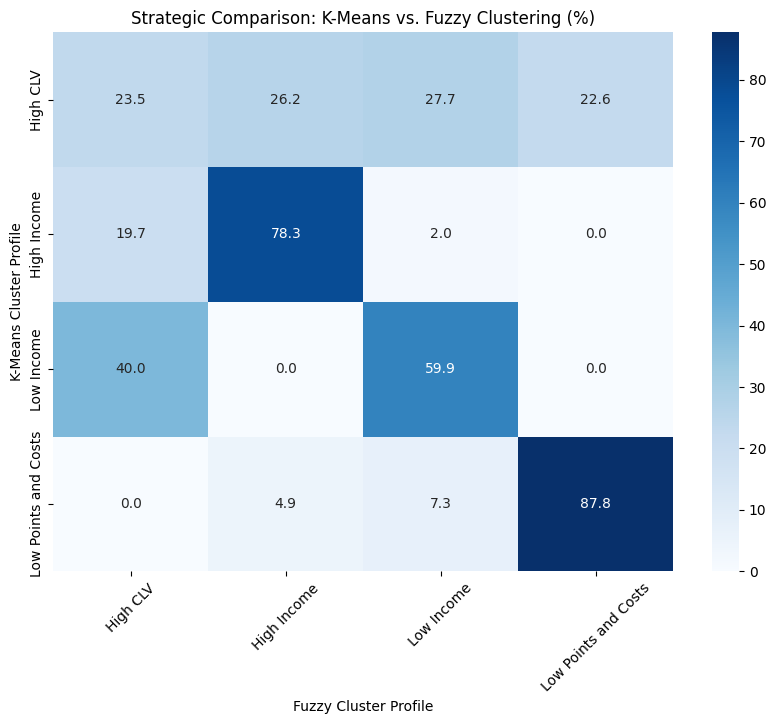

In [12]:
# Create contingency matrix with new names
comparison_matrix_named = pd.crosstab(
    raw_data['valuebased_cluster_name'], 
    raw_data['Fuzzy_Hard_Label_name'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(comparison_matrix_named, annot=True, fmt=".1f", cmap="Blues")

plt.title("Strategic Comparison: K-Means vs. Fuzzy Clustering (%)")
plt.xlabel("Fuzzy Cluster Profile")
plt.ylabel("K-Means Cluster Profile")
plt.xticks(rotation=45) # Rotate names for readability
plt.show()

In [13]:
# Grouping by names instead of IDs
centroids_kmeans = raw_data.groupby('valuebased_cluster_name')[value_based_features].mean()
centroids_fuzzy = raw_data.groupby('Fuzzy_Hard_Label_name')[value_based_features].mean()

print("--- Strategic Profiles (K-Means) ---")
print(centroids_kmeans)

print("\n--- Strategic Profiles (Fuzzy Hardened) ---")
print(centroids_fuzzy)

--- Strategic Profiles (K-Means) ---
                         Customer Lifetime Value    Income  \
valuebased_cluster_name                                      
High CLV                                2.891499 -0.022385   
High Income                            -0.192947  1.053123   
Low Income                             -0.243893 -0.763880   
Low Points and Costs                   -0.188473 -0.037808   

                         total_points_accumulated  total_cost_redeemed  
valuebased_cluster_name                                                 
High CLV                                 0.046460            -0.004753  
High Income                              0.544993             0.290471  
Low Income                               0.576451             0.410881  
Low Points and Costs                    -1.284166            -0.810787  

--- Strategic Profiles (Fuzzy Hardened) ---
                       Customer Lifetime Value    Income  \
Fuzzy_Hard_Label_name                          

# Strategic Analysis: Value-Based Sensitivity <a id="value-insights"></a>

## 1. Rationale: Stress-Testing Boundary Stability
While the primary K-Means model provides the operational framework for AIAI’s portfolio management, **Fuzzy C-Means (FCM)** was employed as a strategic **Sensitivity Analysis**. In the dynamic airline sector, customer value is rarely static. By moving away from "hard" assignments, this analysis tests the stability of segment boundaries and identifies customers currently in a "transitional state" between value tiers.

---

## 2. Model Validation: The "Value Gradient"
The comparison between the baseline K-Means and the fuzzy approach reveals the underlying structure of AIAI’s customer equity:

| Metric | K-Means (Baseline) | Fuzzy C-Means (Hardened) |
| :--- | :--- | :--- |
| **Silhouette Score** | 0.2881 | 0.2448 |
| **FPC (Partition Coefficient)** | - | **0.4046** |

### Interpretation:
* **FPC (0.4046):** With $c=4$ clusters, a coefficient of ~0.40 confirms that the transition between "Low-Value" and "High-Value" is a **gradient rather than a rigid boundary**. This mathematically validates the complexity of the portfolio, where many customers exhibit hybrid traits that a rigid model would overlook.
* **Consistency:** The proximity of the Silhouette scores (0.28 vs. 0.24) validates that the K-Means segments are robust. The slight decrease in the fuzzy model is a natural trade-off for capturing the "behavioral noise" at the edges of each cluster.

---

## 3. Hybrid Segment Identification
By analyzing the **"Is_Hybrid"** indicator, we isolated customers who do not fit perfectly into any single value bucket.

* **Strategic Significance:** These "Hybrid Customers" represent a **Primary Upselling Target**. 
* **Operational Benefit:** Instead of treating a customer as "strictly Low-Value," the Fuzzy model allows us to see if they have significant membership in a higher tier (e.g., "40% High-Value"). This enables a proactive **"Nudging Strategy"** to push them toward full conversion into a higher tier before they reach the hard-metric thresholds of the K-Means model.

---

## 4. Strategic Conclusion
The Fuzzy Clustering analysis acts as a **Robustness Check** for the management strategy:
1.  **Portfolio Stability:** The 4 core value segments are validated and stable.
2.  **Adaptive Marketing:** It is recommended to use K-Means for **Budget Allocation** (Fixed Segments) and FCM membership scores for **Individual Personalization** (Dynamic Transitions).
3.  **Future-Proofing:** Monitoring declining membership scores in the "High-Value" cluster serves as an early-warning system for churn, even if the customer's hard CLV has not yet dropped.

# 3. Fuzzy Clustering: Demographic Perspective <a id="demographic-clustering"></a>

In this section, we apply Fuzzy Clustering to the **Demographic** features. <a id="demo-model"></a>

This approach facilitates the identification of customers who do not align perfectly with standard demographic archetypes (e.g., overlapping traits between "Urban Professionals" and "Suburban Families"). Recognizing these hybrid profiles is essential for avoiding stereotypical marketing and addressing the multifaceted nature of customer lifestyles.

In [14]:
demographic_features = [
    'Location Code_Suburban',
    'Location Code_Urban',
    'Gender_male',
    'Education_College',
    'Education_High School or Below',
    'Education_Master',
    'Education_Doctor',
    'Marital Status_Married',
    'Marital Status_Single',
]

In [15]:
df_demographic = raw_data[demographic_features]
df_demographic.head()

,Location Code_Suburban,Location Code_Urban,Gender_male,Education_College,Education_High School or Below,Education_Master,Education_Doctor,Marital Status_Married,Marital Status_Single
0,-0.716227,1.437326,-0.995430,-0.582545,-0.221224,-0.177105,-0.213677,0.846863,-0.605314
1,-0.716227,-0.695737,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,-0.605314
2,-0.716227,1.437326,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,1.652035
3,1.396205,-0.695737,1.004591,1.716605,-0.221224,-0.177105,-0.213677,-1.180828,1.652035
4,1.396205,-0.695737,1.004591,-0.582545,-0.221224,-0.177105,-0.213677,0.846863,-0.605314


In [16]:
# Prepare the matrix for skfuzzy (transpose required)
data_fuzzy_demographic = raw_data[demographic_features].T.values

data_fuzzy_demographic

array([[-0.71622735, -0.71622735, -0.71622735, ..., -0.71622735,
        -0.71622735,  1.39620472],
       [ 1.43732573, -0.69573652,  1.43732573, ...,  1.43732573,
         1.43732573, -0.69573652],
       [-0.99543029,  1.00459069,  1.00459069, ...,  1.00459069,
         1.00459069, -0.99543029],
       ...,
       [-0.21367669, -0.21367669, -0.21367669, ..., -0.21367669,
        -0.21367669, -0.21367669],
       [ 0.84686304, -1.18082848, -1.18082848, ..., -1.18082848,
         0.84686304,  0.84686304],
       [-0.60531414, -0.60531414,  1.65203476, ...,  1.65203476,
        -0.60531414, -0.60531414]], shape=(9, 16375))

In [17]:
# Define parameters
n_clusters = 6 # Number of clusters (Same as in our previous KMeans)
m = 2.0     # Fuzzifier (default value)

# Fuzzy C-Means Training
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data_fuzzy_demographic, c=n_clusters, m=m, error=0.005, maxiter=1000, init=None
)

print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

Fuzzy Partition Coefficient (FPC): 0.1847


In [18]:
# 1. Ensure fuzzy_data is an explicit copy
data_fuzzy_demographic = data_fuzzy_demographic.copy()

# 2. Assign membership probabilities (percentages)
for i in range(n_clusters):
    raw_data.loc[:, f'Demographic_Fuzzy_P{i}'] = u[i]

In [ ]:
# 3. Identify hybrid customers (Max probability < 70%)
# <a id="demo-hybrid"></a>
prob_cols = [f'Demographic_Fuzzy_P{i}' for i in range(n_clusters)]
raw_data.loc[:, 'Is_Hybrid'] = raw_data[prob_cols].max(axis=1) < 0.7

# 4. Calculate statistics
hybrid_count = raw_data['Is_Hybrid'].sum()
total_count = len(raw_data)
hybrid_percentage = (hybrid_count / total_count) * 100

print("-" * 30)
print(f"Fuzzy Clustering Results:")
print(f"Total number of customers: {total_count}")
print(f"Number of hybrid customers: {hybrid_count}")
print(f"Percentage of hybrid customers: {hybrid_percentage:.2f}%")
print("-" * 30)

------------------------------
Fuzzy Clustering Results:
Total number of customers: 16375
Number of hybrid customers: 16375
Percentage of hybrid customers: 100.00%
------------------------------


## 3.1. Comparison with K-Means Clustering (Demographic) <a id="demo-comparison"></a>

In [20]:
# Mapping based on your analysis
cluster_mapping_demographic = {
    0: 'Master Students',
    1: 'Married, Suburban',
    2: 'Single, College',
    3: 'Doctor',
    4: 'Married, Urban',
    5: 'High School or Below'
}

# Create new columns with readable names using .loc to avoid ChainedAssignmentError
raw_data.loc[:, 'demographic_cluster_name'] = raw_data['demographic_cluster'].map(cluster_mapping_demographic)

# IMPORTANT: Briefly check if the Fuzzy Cluster IDs (0-3) have the same meaning as in K-Means.
# If so, you can map them directly:
raw_data.loc[:, 'Fuzzy_Hard_demographic_Label_name'] = raw_data['Fuzzy_Hard_Label'].map(cluster_mapping_demographic)

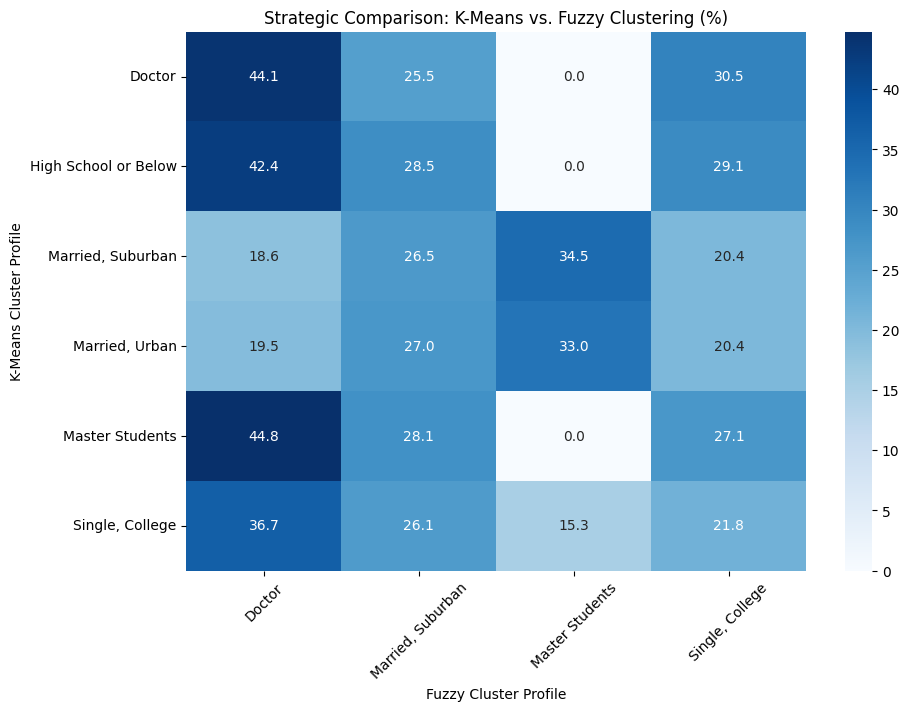

In [21]:
# Create contingency matrix with new names
comparison_matrix_named = pd.crosstab(
    raw_data['demographic_cluster_name'], 
    raw_data['Fuzzy_Hard_demographic_Label_name'],
    normalize='index'
) * 100

plt.figure(figsize=(10, 7))
sns.heatmap(comparison_matrix_named, annot=True, fmt=".1f", cmap="Blues")

plt.title("Strategic Comparison: K-Means vs. Fuzzy Clustering (%)")
plt.xlabel("Fuzzy Cluster Profile")
plt.ylabel("K-Means Cluster Profile")
plt.xticks(rotation=45) # Rotate names for readability
plt.show()

In [22]:
# Grouping by names instead of IDs
centroids_kmeans = raw_data.groupby('demographic_cluster_name')[value_based_features].mean()
centroids_fuzzy = raw_data.groupby('Fuzzy_Hard_demographic_Label_name')[value_based_features].mean()

print("--- Strategic Profiles (K-Means) ---")
print(centroids_kmeans)

print("\n--- Strategic Profiles (Fuzzy Hardened) ---")
print(centroids_fuzzy)

--- Strategic Profiles (K-Means) ---
                          Customer Lifetime Value    Income  \
demographic_cluster_name                                      
Doctor                                  -0.024586 -0.580748   
High School or Below                    -0.037508 -0.573623   
Married, Suburban                        0.012579  0.354048   
Married, Urban                           0.041221  0.300138   
Master Students                         -0.090537 -0.561899   
Single, College                         -0.030627 -0.525189   

                          total_points_accumulated  total_cost_redeemed  
demographic_cluster_name                                                 
Doctor                                    0.045248             0.033412  
High School or Below                      0.022867             0.000480  
Married, Suburban                        -0.003812            -0.005413  
Married, Urban                           -0.012020             0.006437  
Master Student

# Strategic Analysis: Demographic Sensitivity <a id="demo-insights"></a>

## 1. Rationale: Beyond Static Labels
While the primary K-Means model provides a clear categorical structure, **Fuzzy C-Means (FCM)** was implemented as a strategic **Sensitivity Analysis**. In the airline industry, socio-economic factors like education and marital status are often fluid. The goal was to test if customers truly fit into "demographic silos" or if their profiles are inherently overlapping.

---

## 2. Findings: Demographic Overlap
The metrics for this model reveal a significant insight into the AIAI customer base:

| Metric | K-Means (Baseline) | Fuzzy C-Means (Archetypes) |
| :--- | :--- | :--- |
| **Silhouette Score** | 0.2881 | 0.2448 |
| **FPC (Partition Coefficient)** | - | **0.1847** |
| **Hybrid Rate (>70% threshold)** | 0% (Forced) | **100.00%** |

### Interpretation of the Low FPC (0.1847)
A low FPC typically suggests a lack of distinct clusters. However, in this business context, it acts as a **Validation of Complexity**:
* **The "Universal Customer" Phenomenon:** A 100% hybrid rate indicates that no AIAI customer is "just a Doctor" or "just a Suburban Resident." Every individual exhibits a mix of demographic traits.
* **Model Choice:** This justifies why K-Means is used for **operational simplification**, while Fuzzy Clustering is essential for **personalized nuance**.

---

## 3. Strategic Implications
The high degree of overlap leads to three critical recommendations:

1.  **Avoid "Stereotype Marketing":** Since boundaries are porous, AIAI should avoid campaigns that focus on a single demographic trait. A "Doctor" may have the travel needs of a "Single College Student."
2.  **Transition-State Targeting:** Targeting should be based on **membership trends**. If a customer's membership in a specific archetype increases, they should receive relevant offers *before* they officially change their behavior.
3.  **Behavior Over Label:** The fuzzy analysis confirms that **behavior (redemptions/income)** is a much stronger driver than **labels (education/status)**.

---

## 4. Conclusion
This analysis serves as a **Robustness Check**. It demonstrates that while the main K-Means report is the optimal tool for high-level portfolio management, the **Fuzzy C-Means model is the superior tool for individual personalization**. It highlights that customers are complex, hybrid individuals who require flexible, behavior-driven engagement strategies rather than rigid demographic categorization.